In [23]:
import math

import geopandas as gpd
import matplotlib.pyplot as plt
import osmnx as ox
import pandas as pd
import contextily as cx
import yaml
from typing import Optional
from matplotlib.lines import Line2D
from shapely.geometry import Point, Polygon

ox.settings.use_cache = True
ox.settings.log_console = False

with open("../plotting_config.yaml") as fp:
    config = yaml.safe_load(fp)

In [24]:
def plot(
    land,
    street,
    railway,
    bus,
    trolley,
    stops,
    layers=[0],
    axes: Optional[plt.Axes] = None,
):
    ax = axes
    if not axes:
        fig, ax = plt.subplots(figsize=(6, 6), layout="constrained")
    if 0 in layers:
        gpd.clip(land, area).plot(color=config["colors"]["land"], ax=ax, zorder=0)
        gpd.clip(street, area).plot(color=config["colors"]["street"], ax=ax, zorder=1)
    if 1 in layers:
        gpd.clip(railway.query("railway=='tram'"), area).plot(
            color=config["colors"]["tram"], lw=5, ax=ax, zorder=5
        )
    if 2 in layers:
        gpd.clip(railway.query("railway=='subway'"), area).plot(
            color=config["colors"]["m4"], lw=5, ax=ax, zorder=4
        )
    if 3 in layers:
        gpd.clip(bus[bus.geom_type.isin(["LineString", "MultiLineString"])], area).plot(
            color=config["colors"]["bus"], lw=5, ax=ax, zorder=5
        )
    if 4 in layers:
        gpd.clip(
            trolley[
                trolley.geom_type.isin(["LineString", "MultiLineString"])
            ],  # .buffer(1, cap_style=2),
            area,
        ).plot(color=config["colors"]["trolley"], lw=5, ax=ax, zorder=5)
    if 5 in layers:
        gpd.clip(stops, area).plot(color="#2d2d2d", lw=5, ax=ax, zorder=10)
    if 6 in layers:
        gpd.clip(stops, area).plot(color="#2d2d2d", lw=5, ax=ax, zorder=10)

    ax.margins(0)
    ax.axis("off")
    if not axes:
        return fig, ax


def create_legend():
    legend_elements = []
    labels = ["tram", "subway", "bus", "trolley"]
    lcolors = [
        config["colors"][i] if i != "subway" else config["colors"]["m4"] for i in labels
    ]
    for l, c in zip(labels, lcolors):
        elem = Line2D([0], [0], color=c, lw=4, linestyle="solid", label=l)
        legend_elements.append(elem)
    stop = Line2D(
        [0], [0], color="#2d2d2d", lw=4, linestyle="none", marker="o", label="stop"
    )
    legend_elements.append(stop)
    return legend_elements

In [3]:
duna = gpd.read_file("../data/geojson/duna.geojson", engine="pyogrio")
duna.to_crs(23700, inplace=True)

In [4]:
railway = ox.features_from_point(
    (47.4868, 19.057), tags={"railway": ["subway", "tram"]}, dist=500
)
railway.to_crs(23700, inplace=True)

In [5]:
bridge = ox.features_from_point(
    (47.4868, 19.057), tags={"name": "Szabadság híd"}, dist=750
)
bridge.to_crs(23700, inplace=True)
bridge = (
    bridge[bridge["geometry"].geom_type.isin(["Polygon", "MultiPolygon"])]
    .reset_index()
    .copy()
)
bridge = bridge["geometry"][0]

In [6]:
streets = ox.features_from_point((47.4868, 19.057), tags={"highway": True}, dist=500)
streets = streets[
    streets["geometry"].geom_type.isin(["LineString", "MultiLineString"])
].copy()
streets.to_crs(23700, inplace=True)

In [7]:
bus = gpd.read_file("../data/geojson/route_b.geojson", engine="pyogrio")
bus.to_crs(23700, inplace=True)
trolley = gpd.read_file("../data/geojson/route_tb.geojson", engine="pyogrio")
trolley.to_crs(23700, inplace=True)

/home/gergo/.cache/pypoetry/virtualenvs/urbansys-jQN3DqF5-py3.12/lib/python3.12/site-packages/pyogrio/geopandas.py:49: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  res = pd.to_datetime(ser, **datetime_kwargs)
/home/gergo/.cache/pypoetry/virtualenvs/urbansys-jQN3DqF5-py3.12/lib/python3.12/site-packages/pyogrio/geopandas.py:49: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  res = pd.to_datetime(ser, **datetime_kwargs)
/home/gergo/.cache/pypoetry/virtualenvs/urbansys-jQN3DqF5-py3.12/lib/python3.12/site-packages/pyogrio/geopandas.py:49: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  res = pd.to_datetime(ser, **datetime_kwargs)
/home/gergo/.cac

In [9]:
minx = 650700 - 100
miny = 238080 - 100
ax = 250
ay = 250
minx = 650700 - 100 + 75
miny = 238080 - 100 + 25
ax = 150
ay = 150

In [10]:
area = Polygon(
    [
        Point(minx, miny),
        Point(minx + ax, miny),
        Point(minx + ax, miny + ay),
        Point(minx, miny + ay),
    ]
)
land = area - duna.geometry[0]
land = land.union(bridge)
land = gpd.GeoDataFrame(geometry=[land], crs=23700)

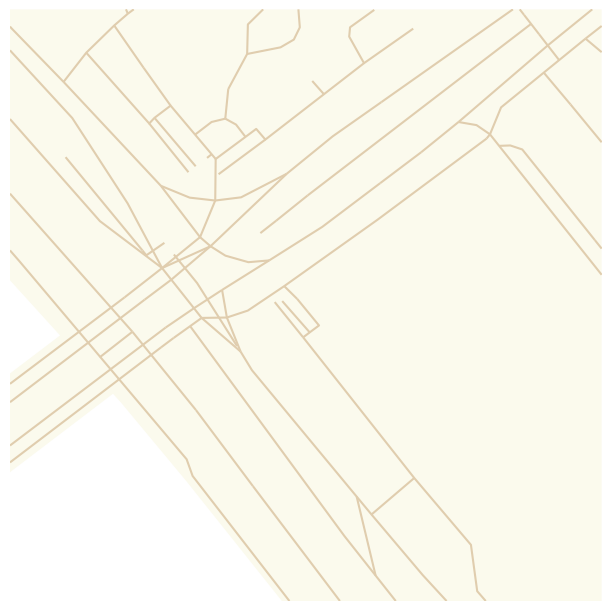

In [189]:
fig, _ = plot(land, streets, None, None, None, None, layers=[0])

In [14]:
stops = pd.concat(
    [
        bus.query("highway=='bus_stop'"),
        trolley.query("highway=='bus_stop'"),
    ]
)
stops.rename({"@id": "osmid", "@type": "element_type"}, axis=1, inplace=True)

In [15]:
rw_stops = ox.features_from_point(
    (47.4868, 19.057),
    tags={"railway": ["tram_stop"], "station": ["subway"], "highway": ["bus_stop"]},
    dist=500,
).reset_index()
rw_stops.to_crs(23700, inplace=True)

In [16]:
stops = pd.concat(
    [
        stops[["element_type", "osmid", "name", "geometry", "railway", "highway"]],
        rw_stops[["element_type", "osmid", "name", "geometry", "railway", "station"]],
    ]
)

In [17]:
stops = rw_stops[
    ["element_type", "osmid", "name", "geometry", "railway", "station"]
].copy()

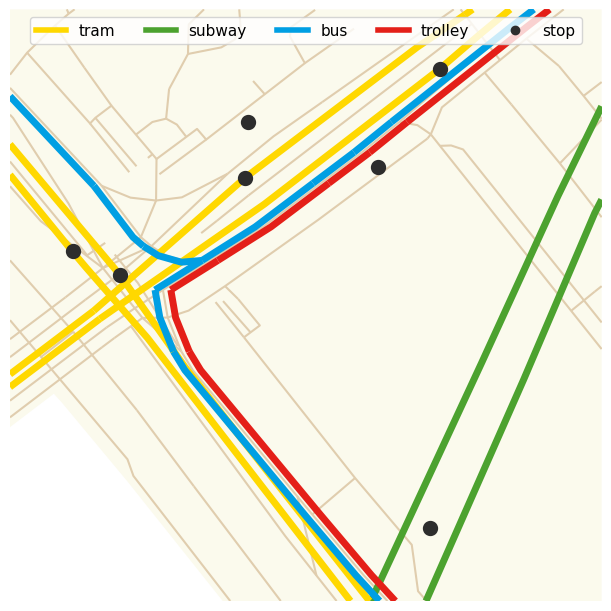

In [195]:
fig2, ax2 = plot(
    land,
    streets,
    railway,
    bus.translate(-2, 0),
    trolley.translate(2, 0),
    stops,
    layers=[0, 1, 2, 3, 4, 5],
)
ax2.legend(handles=create_legend(), ncols=5, loc="upper center", fontsize=11)
for i in config["formats"]:
    fig2.savefig(
        f"../abstract/figures/fovam_with_stops.{i}",
        dpi=300,
        facecolor="white",
        pad_inches=0,
        metadata=config["metadata"] if i != "svg" else None,
    )

In [18]:
fovam_stops = gpd.clip(stops, area)
merged = gpd.GeoDataFrame(geometry=[fovam_stops.unary_union.centroid], crs=23700)

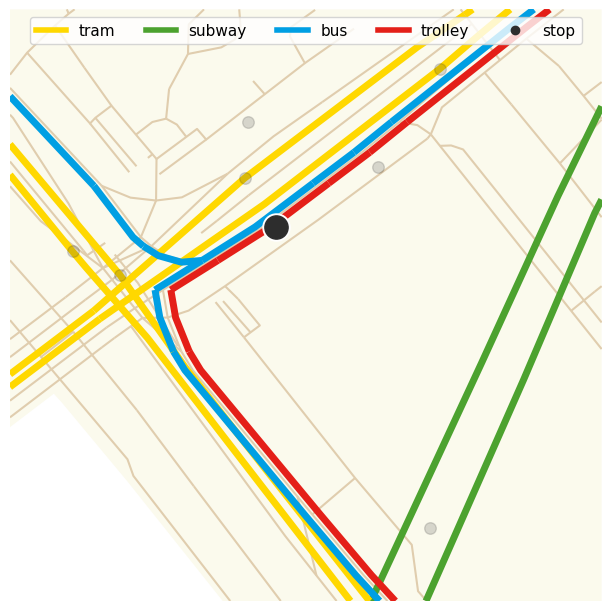

In [194]:
fig3, ax3 = plot(
    land,
    streets,
    railway,
    bus.translate(-2, 0),
    trolley.translate(2, 0),
    None,
    layers=[0, 1, 2, 3, 4],
)
fovam_stops.plot(color="#2d2d2d2d", markersize=70, ax=ax3, zorder=15)
# merged.plot(color="#fbfaed", markersize=380, ax=ax3, zorder=20)
merged.plot(color="#ffffff", markersize=380, ax=ax3, zorder=20)
merged.plot(color="#2d2d2d", markersize=280, ax=ax3, zorder=21)

ax3.legend(handles=create_legend(), ncols=5, loc="upper center", fontsize=11)

for i in config["formats"]:
    fig3.savefig(
        f"../abstract/figures/fovam_stop_substitution.{i}",
        dpi=300,
        facecolor="white",
        pad_inches=0,
        metadata=config["metadata"] if i != "svg" else None,
    )

In [12]:
def calculate_coordinates_with_gap_points(x1, y1, delta_x, delta_y, gap_points):
    # Calculate the length of the line
    L = math.sqrt(delta_x**2 + delta_y**2)

    # Ensure the gap is not more than half the length of the line
    if gap_points * 2 > L:
        raise ValueError("The total gap distance is more than the length of the line.")

    # Calculate the effective length with gaps at both ends
    L_prime = L - 2 * gap_points

    # Calculate the unit direction vector
    unit_x = delta_x / L
    unit_y = delta_y / L

    # Calculate the new deltas for the shortened line
    delta_x_prime = unit_x * L_prime
    delta_y_prime = unit_y * L_prime

    # Calculate the new start coordinates
    new_x1 = x1 + unit_x * gap_points
    new_y1 = y1 + unit_y * gap_points

    # Calculate the new end coordinates
    new_x2 = new_x1 + delta_x_prime
    new_y2 = new_y1 + delta_y_prime

    return new_x1, new_y1, new_x2, new_y2

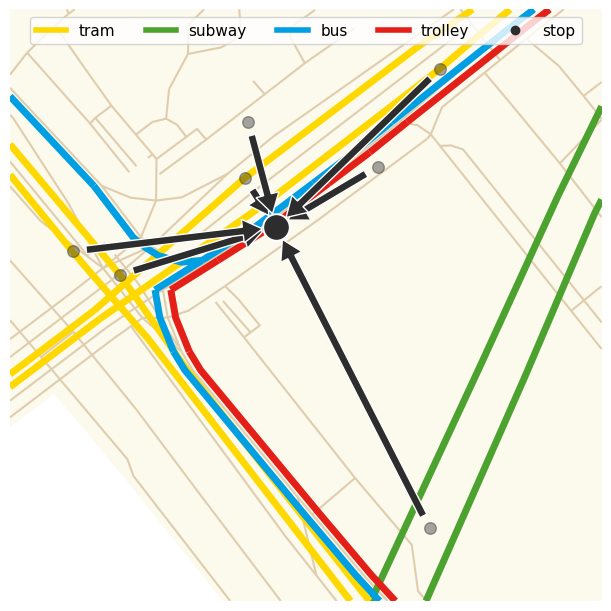

In [193]:
fig4, ax4 = plot(
    land,
    streets,
    railway,
    bus.translate(-2, 0),
    trolley.translate(2, 0),
    stops,
    layers=[0, 1, 2, 3, 4],
)
fovam_stops.plot(color="#2d2d2d6d", markersize=70, ax=ax4, zorder=15)
merged.plot(color="#ffffff", markersize=380, ax=ax4, zorder=20)
merged.plot(color="#2d2d2d", markersize=280, ax=ax4, zorder=21)
ax4.legend(handles=create_legend(), ncols=5, loc="upper center", fontsize=11)

for r in fovam_stops.itertuples():
    m = merged.geometry[0]
    x = r.geometry.x
    y = r.geometry.y
    dx = m.x - x
    dy = m.y - y
    sx, sy, ex, ey = calculate_coordinates_with_gap_points(x, y, dx, dy, 3.5)

    ax4.arrow(
        sx,
        sy,
        ex - sx,
        ey - sy,
        width=2,
        length_includes_head=True,
        head_length=5,
        ec="white",
        color="#2d2d2d",
        zorder=50,
    )
for i in config["formats"]:
    fig4.savefig(
        f"../abstract/figures/fovam_with_stops_arrow.{i}",
        dpi=300,
        facecolor="white",
        pad_inches=0,
        metadata=config["metadata"] if i != "svg" else None,
    )

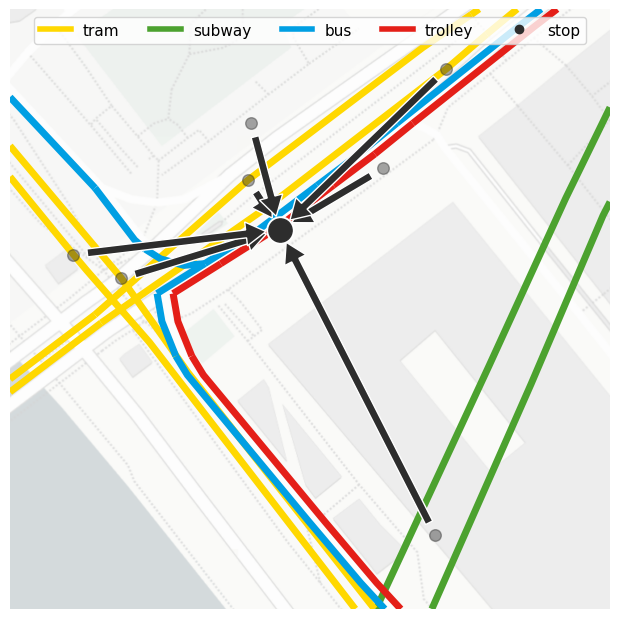

In [26]:
fig5 = plt.figure(figsize=(6, 6))
ax5 = fig5.add_axes([0, 0, 1, 1], frameon=False, xticks=[], yticks=[])
ax5.set_xlim([minx, minx + ax])
ax5.set_ylim([miny, miny + ay])
fovam_stops.plot(color="#2d2d2d6d", markersize=70, ax=ax5, zorder=15)
merged.plot(color="#ffffff", markersize=380, ax=ax5, zorder=20)
merged.plot(color="#2d2d2d", markersize=280, ax=ax5, zorder=21)
ax5.legend(handles=create_legend(), ncols=5, loc="upper center", fontsize=11)

for r in fovam_stops.itertuples():
    m = merged.geometry[0]
    x = r.geometry.x
    y = r.geometry.y
    dx = m.x - x
    dy = m.y - y
    sx, sy, ex, ey = calculate_coordinates_with_gap_points(x, y, dx, dy, 3.5)

    ax5.arrow(
        sx,
        sy,
        ex - sx,
        ey - sy,
        width=2,
        length_includes_head=True,
        head_length=5,
        ec="white",
        color="#2d2d2d",
        zorder=50,
    )
plot(
    land,
    streets,
    railway,
    bus.translate(-2, 0),
    trolley.translate(2, 0),
    stops,
    layers=[1, 2, 3, 4],
    axes=ax5,
)
cx.add_basemap(
    ax5,
    crs=23700,
    source=cx.providers.CartoDB.PositronNoLabels,
    alpha=1,
    attribution=False,
)
for i in config["formats"]:
    fig5.savefig(
        f"../abstract/figures/fovam_with_stops_arrow_cx.{i}",
        dpi=300,
        facecolor="white",
        pad_inches=0,
        metadata=config["metadata"] if i != "svg" else None,
    )